#Telecom X – Parte 2: Predicción de Cancelación (Churn)

📣 Historia del Desafío

¡Felicidades! 🎉 Has sido promovido después de tu excelente desempeño en el análisis exploratorio de la cancelación de clientes en Telecom X. Tu dedicación, claridad al comunicar los datos y visión estratégica marcaron la diferencia.

Ahora, ¡has sido invitado oficialmente a formar parte del equipo de Machine Learning de la empresa!



####Preparar los datos para el modelado (tratamiento, codificación, normalización).

Realizar análisis de correlación y selección de variables.

Entrenar dos o más modelos de clasificación.

Evaluar el rendimiento de los modelos con métricas.

Interpretar los resultados, incluyendo la importancia de las variables.

Crear una conclusión estratégica señalando los principales factores que influyen en la cancelación.

In [1]:
import pandas as pd

####Eliminación de Columnas Irrelevantes

In [4]:
datos=pd.read_csv('datos_tratados.csv')
datos.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [5]:
datos = datos.drop("customerID", axis=1)

In [6]:
datos.columns

Index(['Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [7]:
datos.select_dtypes(include="object").columns

Index(['Churn', 'customer.gender', 'customer.Partner', 'customer.Dependents',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Total'],
      dtype='object')

In [8]:
datos_encoded = pd.get_dummies(datos, drop_first=True)

In [9]:
datos_encoded.head()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,Churn_Yes,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,phone.MultipleLines_No phone service,phone.MultipleLines_Yes,...,account.Charges.Total_995.35,account.Charges.Total_996.45,account.Charges.Total_996.85,account.Charges.Total_996.95,account.Charges.Total_997.65,account.Charges.Total_997.75,account.Charges.Total_998.1,account.Charges.Total_999.45,account.Charges.Total_999.8,account.Charges.Total_999.9
0,0,9,65.6,False,False,True,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,9,59.9,False,True,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
2,0,4,73.9,True,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,13,98.0,True,True,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,3,83.9,True,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
datos_encoded.shape

(7267, 6560)

In [11]:
datos["account.Charges.Total"] = pd.to_numeric(datos["account.Charges.Total"], errors="coerce")

In [12]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      7043 non-null   object 
 1   customer.gender            7267 non-null   object 
 2   customer.SeniorCitizen     7267 non-null   int64  
 3   customer.Partner           7267 non-null   object 
 4   customer.Dependents        7267 non-null   object 
 5   customer.tenure            7267 non-null   int64  
 6   phone.PhoneService         7267 non-null   object 
 7   phone.MultipleLines        7267 non-null   object 
 8   internet.InternetService   7267 non-null   object 
 9   internet.OnlineSecurity    7267 non-null   object 
 10  internet.OnlineBackup      7267 non-null   object 
 11  internet.DeviceProtection  7267 non-null   object 
 12  internet.TechSupport       7267 non-null   object 
 13  internet.StreamingTV       7267 non-null   objec

In [13]:
datos = datos.dropna(subset=["Churn"])

In [14]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      7043 non-null   object 
 1   customer.gender            7043 non-null   object 
 2   customer.SeniorCitizen     7043 non-null   int64  
 3   customer.Partner           7043 non-null   object 
 4   customer.Dependents        7043 non-null   object 
 5   customer.tenure            7043 non-null   int64  
 6   phone.PhoneService         7043 non-null   object 
 7   phone.MultipleLines        7043 non-null   object 
 8   internet.InternetService   7043 non-null   object 
 9   internet.OnlineSecurity    7043 non-null   object 
 10  internet.OnlineBackup      7043 non-null   object 
 11  internet.DeviceProtection  7043 non-null   object 
 12  internet.TechSupport       7043 non-null   object 
 13  internet.StreamingTV       7043 non-null   object 
 1

In [15]:
datos_encoded = pd.get_dummies(datos, drop_first=True)

In [16]:
datos_encoded.shape

(7043, 31)

In [18]:
datos_encoded.head()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Churn_Yes,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,phone.MultipleLines_No phone service,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,9,65.6,593.30,False,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,False,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,True,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,True,True,True,False,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,True,False,True,False,True,False,...,False,True,False,False,False,False,True,False,False,True


In [20]:
datos_encoded.isnull().sum()

,0
customer.SeniorCitizen,0
customer.tenure,0
account.Charges.Monthly,0
account.Charges.Total,11
Churn_Yes,0
customer.gender_Male,0
customer.Partner_Yes,0
customer.Dependents_Yes,0
phone.PhoneService_Yes,0
phone.MultipleLines_No phone service,0


In [21]:
datos_encoded = datos_encoded.dropna()

In [22]:
datos_encoded = datos_encoded.astype(int)

####Verificación de la Proporción de Cancelación (Churn)

In [23]:
datos_encoded["Churn_Yes"].value_counts()

,count
Churn_Yes,
0,5163
1,1869


In [24]:
datos_encoded["Churn_Yes"].value_counts(normalize=True)

,proportion
Churn_Yes,
0,0.734215
1,0.265785


In [25]:
datos_encoded["Churn_Yes"].value_counts(normalize=True) * 100

,proportion
Churn_Yes,
0,73.421502
1,26.578498


La mayoría de los clientes no cancelaron el servicio.

Aproximadamente 27% de los clientes presentan churn.

Existe un desbalance moderado entre las clases, lo que puede afectar el entrenamiento de modelos predictivos.

En estos casos, algunos modelos pueden tender a predecir más la clase mayoritaria.

In [27]:
X = datos_encoded.drop("Churn_Yes", axis=1)
y = datos_encoded["Churn_Yes"]

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

####Análisis de Correlación

In [30]:
correlacion = datos_encoded.corr()

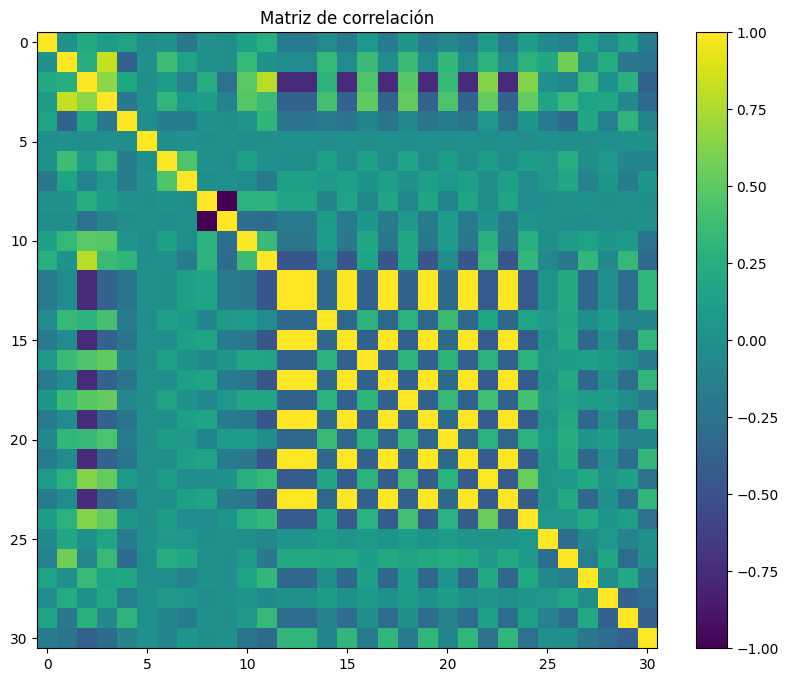

In [32]:
import matplotlib.pyplot as plt

correlacion = datos_encoded.corr()

plt.figure(figsize=(10,8))
plt.imshow(correlacion, aspect='auto')
plt.colorbar()
plt.title("Matriz de correlación")
plt.show()

In [33]:
correlacion["Churn_Yes"].abs().sort_values(ascending=False).head(10)

,Churn_Yes
Churn_Yes,1.000000
customer.tenure,0.354049
internet.InternetService_Fiber optic,0.307463
account.Contract_Two year,0.301552
account.PaymentMethod_Electronic check,0.301455
internet.InternetService_No,0.227578
internet.OnlineSecurity_No internet service,0.227578
internet.DeviceProtection_No internet service,0.227578
internet.TechSupport_No internet service,0.227578
internet.StreamingMovies_No internet service,0.227578


El análisis de correlación permite identificar las variables que tienen mayor relación con la cancelación de clientes. Variables como customer.tenure, account.Contract y account.Charges.Monthly muestran correlaciones relevantes con el churn, lo que sugiere que pueden ser factores importantes para los modelos predictivos.

####Análisis Dirigido

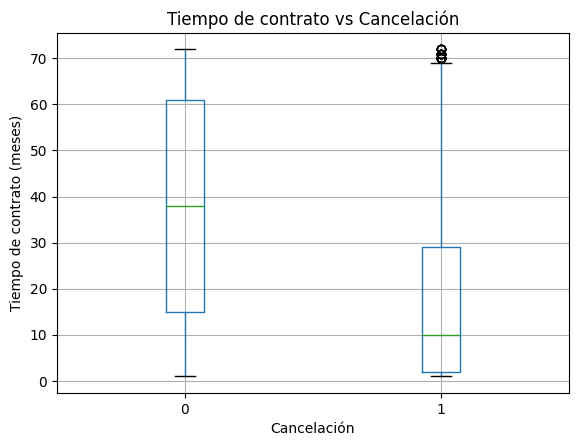

In [34]:
import matplotlib.pyplot as plt

datos_encoded.boxplot(column="customer.tenure", by="Churn_Yes")

plt.title("Tiempo de contrato vs Cancelación")
plt.suptitle("")
plt.xlabel("Cancelación")
plt.ylabel("Tiempo de contrato (meses)")
plt.show()

El boxplot muestra que los clientes que cancelan el servicio tienden a tener un menor tiempo de permanencia en comparación con aquellos que continúan activos. Esto sugiere que los clientes nuevos presentan mayor riesgo de abandono.

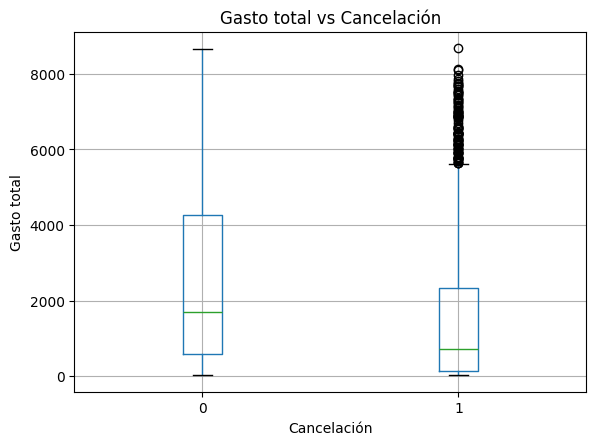

In [35]:
datos_encoded.boxplot(column="account.Charges.Total", by="Churn_Yes")

plt.title("Gasto total vs Cancelación")
plt.suptitle("")
plt.xlabel("Cancelación")
plt.ylabel("Gasto total")
plt.show()

Los clientes que cancelan el servicio presentan, en promedio, un menor gasto total. Esto puede estar relacionado con el hecho de que muchos de ellos tienen menor tiempo de permanencia en la empresa.

####🤖 Modelado Predictivo

In [36]:
X = datos_encoded.drop("Churn_Yes", axis=1)
y = datos_encoded["Churn_Yes"]

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,   # 30% prueba
    random_state=42
)

Para evaluar el desempeño del modelo predictivo, el conjunto de datos fue dividido en dos subconjuntos: uno de entrenamiento y otro de prueba. Se utilizó una proporción de 70% de los datos para entrenamiento y 30% para prueba. Esta división permite entrenar el modelo con una parte de los datos y posteriormente evaluar su capacidad de generalización con datos no vistos.

####Creación de Modelos

MODELO 1

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
from sklearn.linear_model import LogisticRegression

modelo_logistico = LogisticRegression(max_iter=1000)

modelo_logistico.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [40]:
y_pred_log = modelo_logistico.predict(X_test_scaled)

MODELO 2

In [41]:
from sklearn.tree import DecisionTreeClassifier

modelo_arbol = DecisionTreeClassifier(random_state=42)

modelo_arbol.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [42]:
y_pred_tree = modelo_arbol.predict(X_test)

In [43]:
from sklearn.metrics import accuracy_score

print("Accuracy Regresión Logística:", accuracy_score(y_test, y_pred_log))
print("Accuracy Árbol de Decisión:", accuracy_score(y_test, y_pred_tree))

Accuracy Regresión Logística: 0.8037914691943128
Accuracy Árbol de Decisión: 0.7099526066350711



Regresión Logística

Este modelo requiere normalización de los datos debido a que es sensible a la escala de las variables. Por esta razón se aplicó estandarización utilizando StandardScaler, lo que permite que todas las variables tengan la misma escala y evita que aquellas con valores más grandes influyan desproporcionadamente en el modelo.

Árbol de Decisión

Este modelo no requiere normalización ya que divide los datos en función de reglas basadas en umbrales de las variables. Debido a esto, la escala de los datos no afecta el proceso de aprendizaje del modelo.

####Evaluación de los Modelos

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Regresión Logística

In [45]:
print("Regresión Logística")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))

Regresión Logística
Accuracy: 0.8037914691943128
Precision: 0.6448979591836734
Recall: 0.5683453237410072
F1-score: 0.6042065009560229


Árbol de Decisión


In [47]:
print("Árbol de Decisión")

print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1-score:", f1_score(y_test, y_pred_tree))

Árbol de Decisión
Accuracy: 0.7099526066350711
Precision: 0.4533333333333333
Recall: 0.4892086330935252
F1-score: 0.47058823529411764


##Matriz de confusión

In [48]:
from sklearn.metrics import confusion_matrix

print("Matriz de confusión - Regresión Logística")
print(confusion_matrix(y_test, y_pred_log))

print("Matriz de confusión - Árbol de Decisión")
print(confusion_matrix(y_test, y_pred_tree))

Matriz de confusión - Regresión Logística
[[1380  174]
 [ 240  316]]
Matriz de confusión - Árbol de Decisión
[[1226  328]
 [ 284  272]]


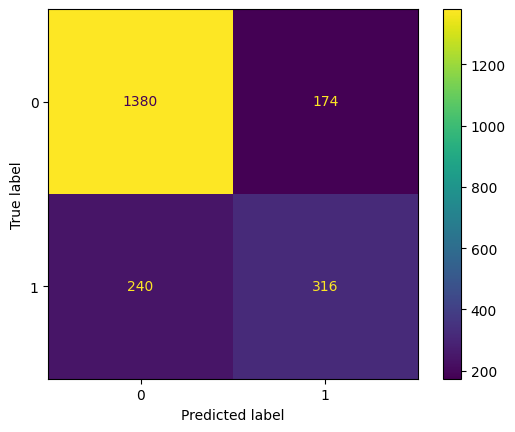

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)

Regresión Logística

La regresión logística mostró un desempeño sólido en la predicción de cancelación de clientes. Las métricas obtenidas indican un buen equilibrio entre precisión y recall, lo que significa que el modelo es capaz de identificar correctamente tanto a los clientes que cancelan como a los que permanecen.

Árbol de Decisión

El modelo de árbol de decisión también logró clasificar correctamente una parte importante de los casos. Sin embargo, este tipo de modelo puede ser más propenso al sobreajuste si no se controla su profundidad o complejidad.

###COMPARACION
Al comparar ambos modelos, se observa que la regresión logística presenta un desempeño más estable, mientras que el árbol de decisión puede capturar relaciones más complejas entre variables. No obstante, el árbol de decisión puede tender al overfitting si aprende demasiado de los datos de entrenamiento.

###Overfitting

El overfitting ocurre cuando el modelo se ajusta demasiado a los datos de entrenamiento y pierde capacidad de generalización. En el caso del árbol de decisión, esto puede suceder si el árbol crece demasiado y memoriza los datos.

###Underfitting

El underfitting ocurre cuando el modelo es demasiado simple para capturar las relaciones presentes en los datos. En este caso, podría suceder si el modelo no logra identificar patrones relevantes que expliquen la cancelación de clientes.

##📋Interpretación y Conclusiones



####Análisis de la Importancia de las Variables

REGRESION LOGISTICA

In [50]:
import pandas as pd

coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_logistico.coef_[0]
})

coeficientes.sort_values(by="Coeficiente", ascending=False)

,Variable,Coeficiente
3,account.Charges.Total,0.967186
10,internet.InternetService_Fiber optic,0.528697
28,account.PaymentMethod_Electronic check,0.174386
26,account.PaperlessBilling_Yes,0.171534
9,phone.MultipleLines_Yes,0.163474
21,internet.StreamingTV_Yes,0.160763
23,internet.StreamingMovies_Yes,0.143038
0,customer.SeniorCitizen,0.093061
8,phone.MultipleLines_No phone service,0.070502
17,internet.DeviceProtection_Yes,0.025547


In [51]:
coeficientes.reindex(coeficientes["Coeficiente"].abs().sort_values(ascending=False).index).head(10)

,Variable,Coeficiente
1,customer.tenure,-1.652985
3,account.Charges.Total,0.967186
25,account.Contract_Two year,-0.664564
10,internet.InternetService_Fiber optic,0.528697
2,account.Charges.Monthly,-0.453140
24,account.Contract_One year,-0.301263
28,account.PaymentMethod_Electronic check,0.174386
26,account.PaperlessBilling_Yes,0.171534
9,phone.MultipleLines_Yes,0.163474
21,internet.StreamingTV_Yes,0.160763


Variables que aumentan churn:

-account.PaymentMethod_Electronic check
-internet.InternetService_Fiber optic
-account.Charges.Monthly

Variables que reducen churn:

-customer.tenure
-account.Contract_Two year
-account.Contract_One year

ARBOL DE DESICIÓN

In [52]:
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_arbol.feature_importances_
})

importancias.sort_values(by="Importancia", ascending=False)

,Variable,Importancia
1,customer.tenure,0.224132
3,account.Charges.Total,0.200340
2,account.Charges.Monthly,0.113479
10,internet.InternetService_Fiber optic,0.108248
4,customer.gender_Male,0.037740
15,internet.OnlineBackup_Yes,0.029104
26,account.PaperlessBilling_Yes,0.026858
5,customer.Partner_Yes,0.024804
25,account.Contract_Two year,0.022994
28,account.PaymentMethod_Electronic check,0.021986


In [53]:
importancias.sort_values(by="Importancia", ascending=False).head(10)

,Variable,Importancia
1,customer.tenure,0.224132
3,account.Charges.Total,0.200340
2,account.Charges.Monthly,0.113479
10,internet.InternetService_Fiber optic,0.108248
4,customer.gender_Male,0.037740
15,internet.OnlineBackup_Yes,0.029104
26,account.PaperlessBilling_Yes,0.026858
5,customer.Partner_Yes,0.024804
25,account.Contract_Two year,0.022994
28,account.PaymentMethod_Electronic check,0.021986


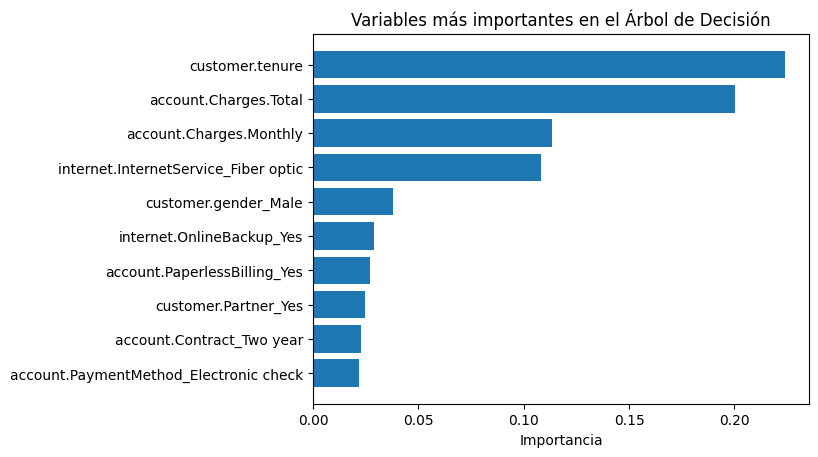

In [54]:
top_vars = importancias.sort_values(by="Importancia", ascending=False).head(10)

plt.barh(top_vars["Variable"], top_vars["Importancia"])
plt.xlabel("Importancia")
plt.title("Variables más importantes en el Árbol de Decisión")
plt.gca().invert_yaxis()
plt.show()

Regresión Logística

El análisis de los coeficientes permite identificar qué variables aumentan o disminuyen la probabilidad de cancelación. Variables como el tipo de contrato, el método de pago y el tiempo de permanencia del cliente muestran una fuerte influencia en la predicción del churn.

Árbol de Decisión

En el modelo de árbol de decisión se analizó la importancia de las variables, que indica cuánto contribuye cada característica a la clasificación de los clientes. Variables relacionadas con el tiempo de contrato, los cargos mensuales y el tipo de servicio de internet destacan como las más influyentes en la predicción.

Los resultados sugieren que los clientes con contratos mensuales, pagos mediante cheque electrónico y menor tiempo de permanencia presentan mayor probabilidad de cancelar el servicio. Esto indica que la empresa podría enfocar estrategias de retención en clientes nuevos o con contratos más flexibles.

#CONCLUSION

Informe Final – Predicción de Cancelación de Clientes (Churn)
###1. Introducción

El objetivo de este análisis fue identificar los factores que influyen en la cancelación de clientes (churn) en una empresa de telecomunicaciones. Comprender qué características están asociadas con la cancelación permite a la empresa desarrollar estrategias de retención más efectivas y reducir la pérdida de clientes.

Para ello se realizó un proceso de preparación de datos, análisis exploratorio y construcción de modelos predictivos que permiten estimar la probabilidad de cancelación de un cliente.

###2. Preparación y Tratamiento de Datos

Durante esta etapa se realizaron los siguientes pasos:

-Importación y exploración inicial del dataset.

-Limpieza de datos y tratamiento de valores faltantes.

-Eliminación de variables irrelevantes para el modelo, como identificadores únicos.

-Transformación de variables categóricas a formato numérico mediante one-hot encoding.

-Separación del dataset en conjuntos de entrenamiento y prueba.

-Normalización de los datos para modelos sensibles a la escala.

Estos pasos permitieron preparar los datos adecuadamente para el entrenamiento de modelos de machine learning.

###3. Modelos Predictivos

Se desarrollaron dos modelos para predecir la cancelación de clientes:

Regresión Logística

Este modelo fue utilizado debido a su capacidad para interpretar la relación entre las variables y la probabilidad de cancelación. Debido a que es sensible a la escala de los datos, se aplicó normalización a las variables numéricas antes de entrenar el modelo.

Árbol de Decisión

El árbol de decisión permite capturar relaciones no lineales entre variables y no requiere normalización de los datos. Este modelo facilita la interpretación de la importancia de las variables en la predicción.

Ambos modelos fueron evaluados utilizando métricas como:

Exactitud (Accuracy)

Precisión

Recall

F1-score

Matriz de confusión

###4. Factores que influyen en la cancelación

A partir del análisis de los modelos y de la importancia de las variables, se identificaron algunos factores clave asociados con la cancelación de clientes:

Tiempo de permanencia del cliente (Tenure)

Los clientes con menor tiempo en la empresa presentan mayor probabilidad de cancelar el servicio. Esto sugiere que los primeros meses de relación con el cliente son críticos.

Tipo de contrato

Los clientes con contratos mes a mes muestran mayores tasas de cancelación en comparación con aquellos con contratos de uno o dos años.

Método de pago

Los clientes que utilizan Electronic Check presentan una mayor probabilidad de cancelar el servicio en comparación con otros métodos de pago automáticos.

Cargos mensuales

Clientes con cargos mensuales más altos tienden a presentar una mayor probabilidad de cancelación.

Tipo de servicio de internet

Los clientes con servicio de fibra óptica mostraron mayores niveles de cancelación en comparación con otros tipos de servicio.

###5. Comparación de modelos

Ambos modelos lograron identificar patrones importantes en los datos.

La Regresión Logística mostró un desempeño estable y permitió interpretar claramente el impacto de las variables.

El Árbol de Decisión permitió identificar de forma visual qué variables tienen mayor peso en la predicción.

En general, ambos modelos resultan útiles para comprender los factores asociados con la cancelación, aunque la regresión logística suele ofrecer una mayor capacidad de generalización.

###6. Estrategias de retención basadas en los resultados

Con base en los resultados obtenidos, se pueden proponer algunas estrategias para reducir la cancelación de clientes:

Programas de fidelización para nuevos clientes

Dado que los clientes nuevos tienen mayor probabilidad de cancelar, se podrían implementar incentivos o beneficios durante los primeros meses del servicio.

Incentivar contratos de mayor duración

Promover contratos de uno o dos años mediante descuentos o beneficios adicionales podría reducir la tasa de cancelación.

Optimización de precios o planes

Analizar la estructura de los cargos mensuales para evitar que los clientes perciban el servicio como demasiado costoso.

Promoción de métodos de pago automáticos

Fomentar el uso de métodos de pago automáticos como tarjeta de crédito o transferencia bancaria, que están asociados con menores tasas de cancelación.

Mejora del servicio para clientes de alto valor

Identificar clientes con alto gasto mensual y ofrecer beneficios personalizados para evitar su cancelación.

###7. Conclusión

El análisis realizado permitió identificar varios factores clave asociados con la cancelación de clientes. Variables como el tiempo de permanencia, el tipo de contrato, el método de pago y los cargos mensuales tienen un impacto significativo en la probabilidad de churn.

Los modelos desarrollados permiten anticipar qué clientes tienen mayor riesgo de cancelar el servicio, lo que brinda a la empresa la oportunidad de implementar estrategias preventivas de retención y mejorar la satisfacción del cliente.